# Telco Churn - Initial Data Inspection

Phase 0 quick sanity checks before full EDA.

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nInfo:")
df.info()
print("\nDescribe (numeric):")
print(df.describe())
print("\nChurn distribution (normalized):")
print(df["Churn"].value_counts(normalize=True))
print("\nHead:")
print(df.head())

Shape: (7043, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner          

## Section 1: Data Quality Audit

This section classifies columns and checks core data quality issues before visualization.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
churn_palette = ["#3498db", "#e74c3c"]

id_col = ["customerID"]
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
]
multiclass_categorical_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]
ordinal_like_categorical_cols = ["Contract", "PaymentMethod"]

all_categorical_cols = (
    binary_categorical_cols
    + multiclass_categorical_cols
    + ordinal_like_categorical_cols
)

print("Column groups:")
print(f"ID: {id_col}")
print(f"Numeric: {numeric_cols}")
print(f"Binary categorical: {binary_categorical_cols}")
print(f"Multiclass categorical: {multiclass_categorical_cols}")
print(f"Ordinal-like categorical: {ordinal_like_categorical_cols}")

print("\nData quality checks:")
blank_total_charges = df[df["TotalCharges"] == " "]
print(f"Rows with blank TotalCharges: {len(blank_total_charges)}")
print(blank_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head())

print("\nNull values per column:")
print(df.isnull().sum())

duplicate_ids = df["customerID"].duplicated().sum()
print(f"\nDuplicate customerID rows: {duplicate_ids}")

summary_table = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "null_count": df.isnull().sum().values,
        "unique_count": [df[col].nunique(dropna=False) for col in df.columns],
    }
)
print("\nColumn summary table:")
print(summary_table)

print("\nUnique value counts (categorical columns):")
for col in all_categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

Column groups:
ID: ['customerID']
Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Multiclass categorical: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
Ordinal-like categorical: ['Contract', 'PaymentMethod']

Data quality checks:
Rows with blank TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No

Null values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
Ph

## Section 2: Target Variable Analysis

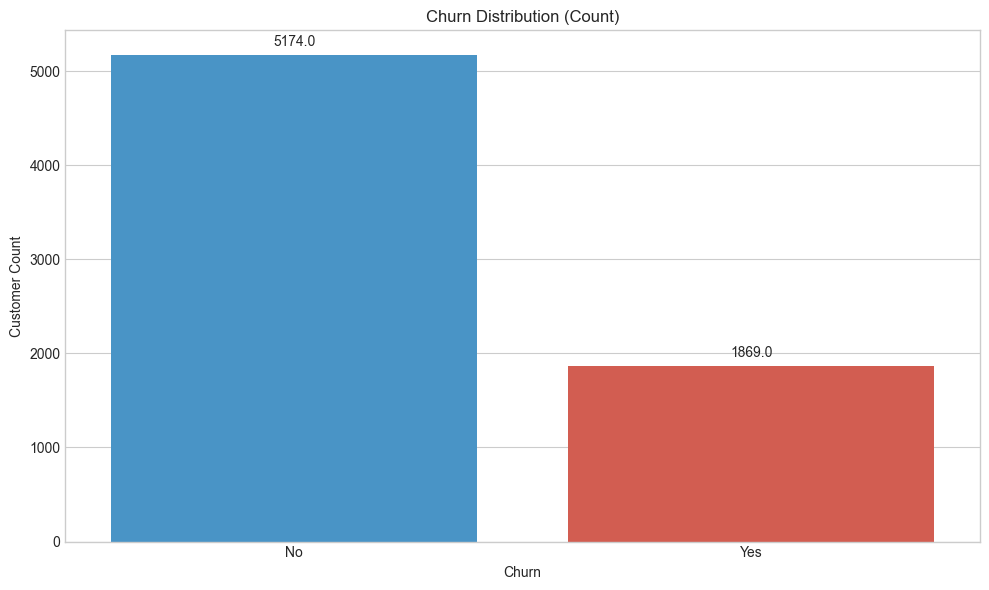

Class ratio (normalized):
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Imbalance summary: 73.46% No vs 26.54% Yes
This is a moderate imbalance and should be handled in modeling with class weights and/or resampling.


In [3]:
churn_counts = df["Churn"].value_counts()
churn_ratio = df["Churn"].value_counts(normalize=True)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette=churn_palette, legend=False)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

plt.title("Churn Distribution (Count)")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

print("Class ratio (normalized):")
print(churn_ratio)
print(
    f"\nImbalance summary: {churn_ratio.get('No', 0):.2%} No vs {churn_ratio.get('Yes', 0):.2%} Yes"
)
print("This is a moderate imbalance and should be handled in modeling with class weights and/or resampling.")

## Section 3: Univariate Analysis - Numeric Features

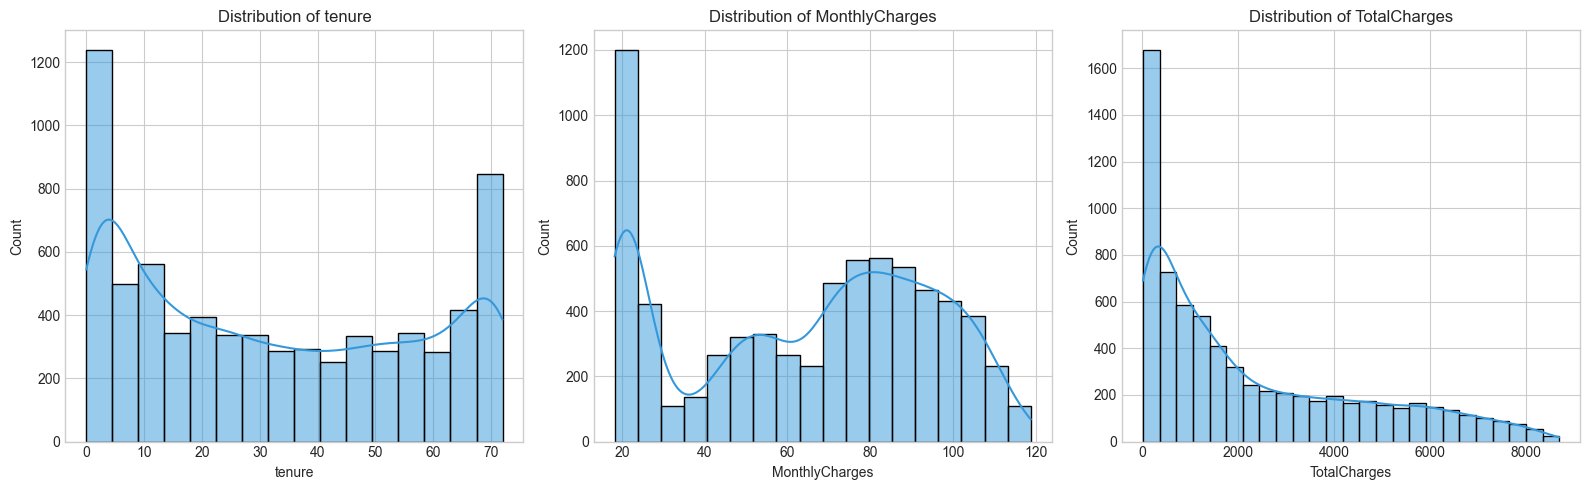

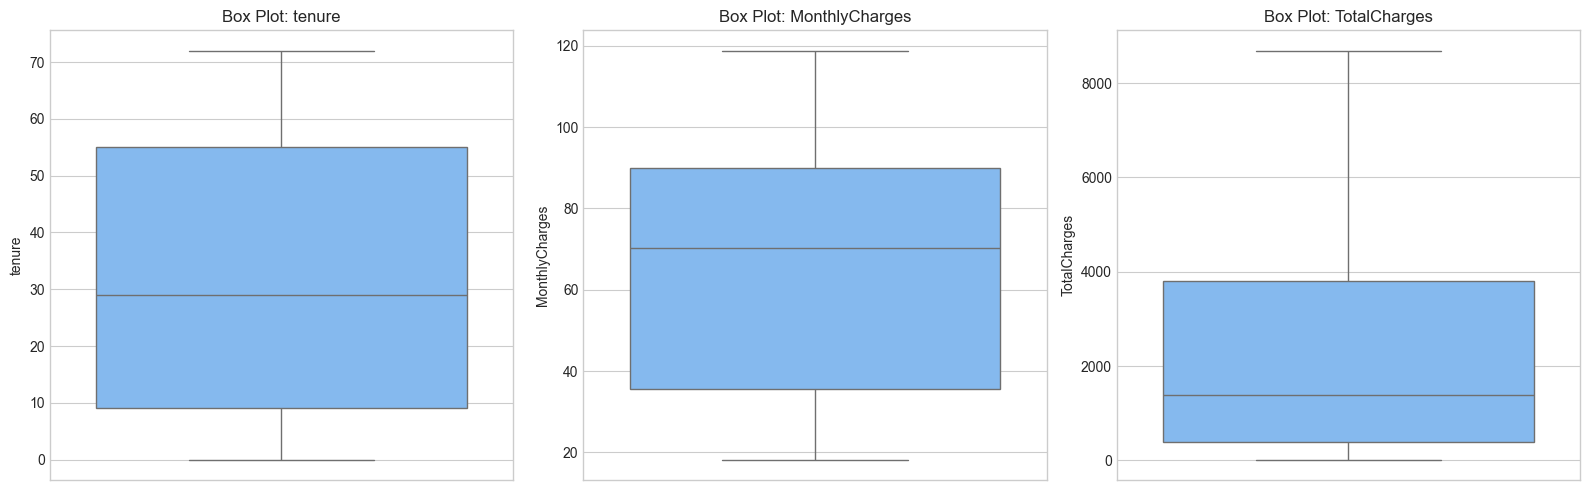

In [4]:
# Convert TotalCharges to numeric only for analysis (in-memory)
df_numeric = df.copy()
df_numeric["TotalCharges"] = pd.to_numeric(df_numeric["TotalCharges"], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(df_numeric[col], kde=True, ax=axes[i], color="#3498db")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(y=df_numeric[col], ax=axes[i], color="#74b9ff")
    axes[i].set_title(f"Box Plot: {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## Section 4: Univariate Analysis - Categorical Features

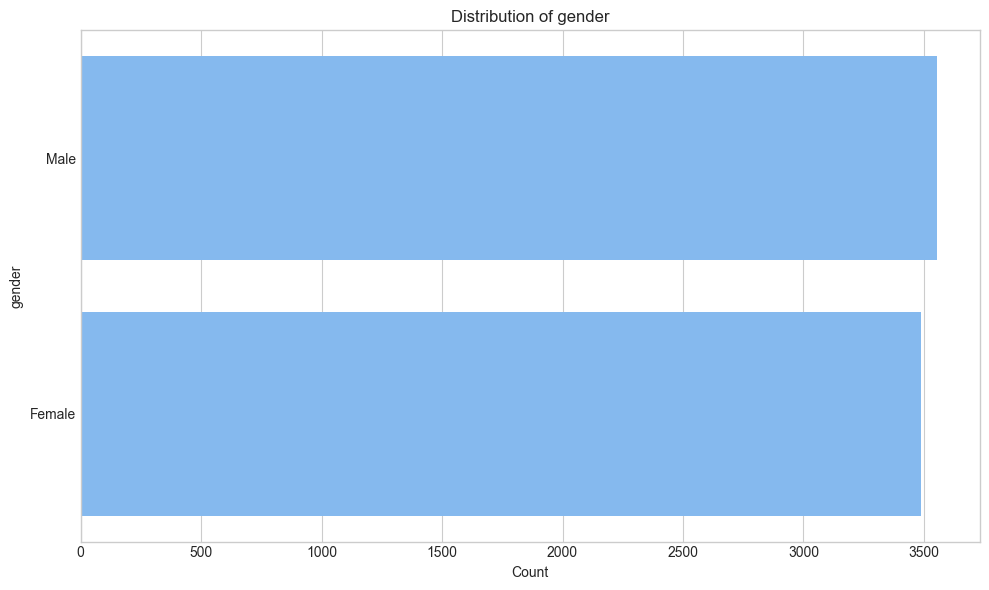

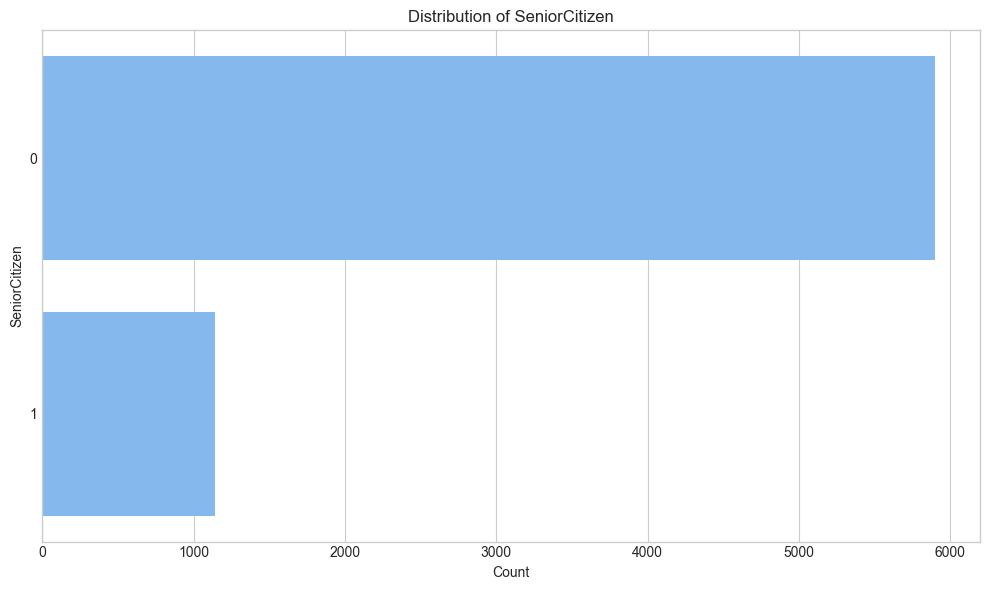

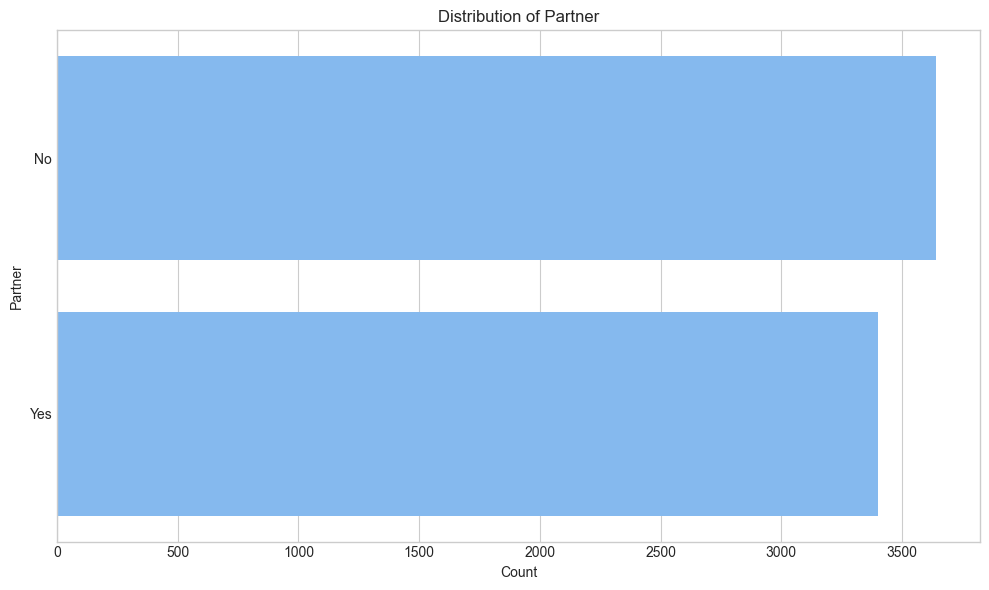

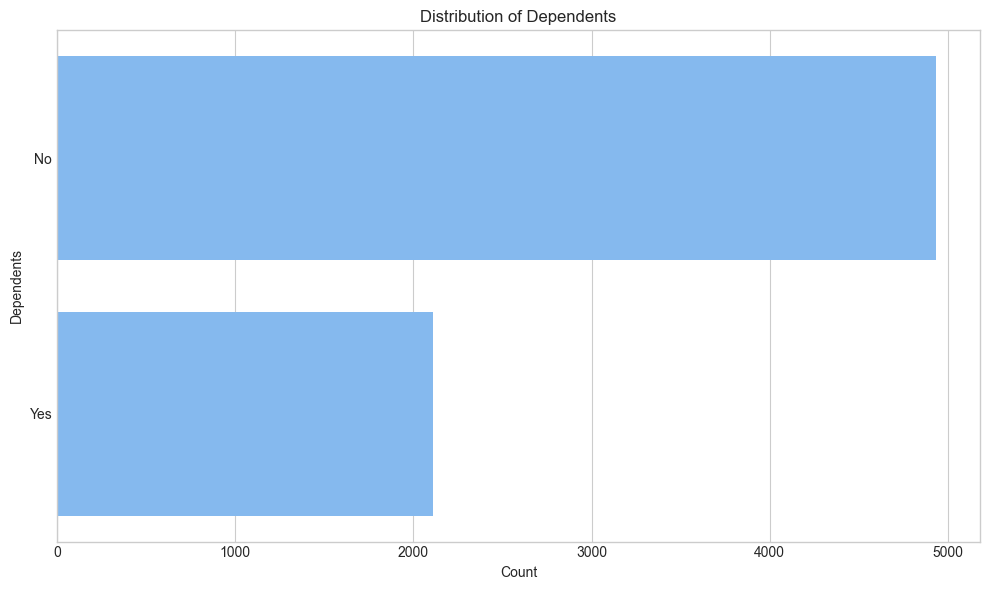

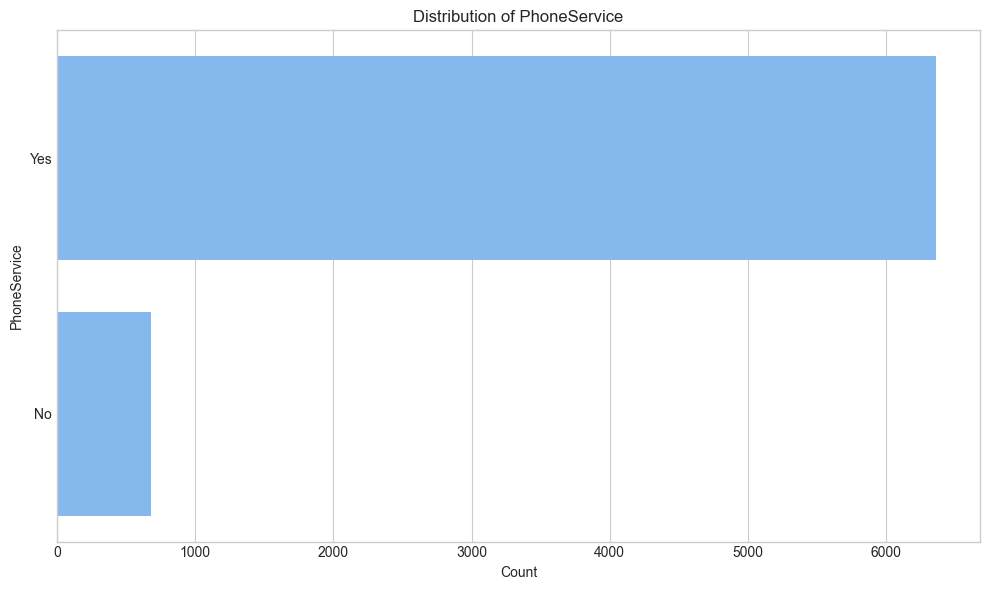

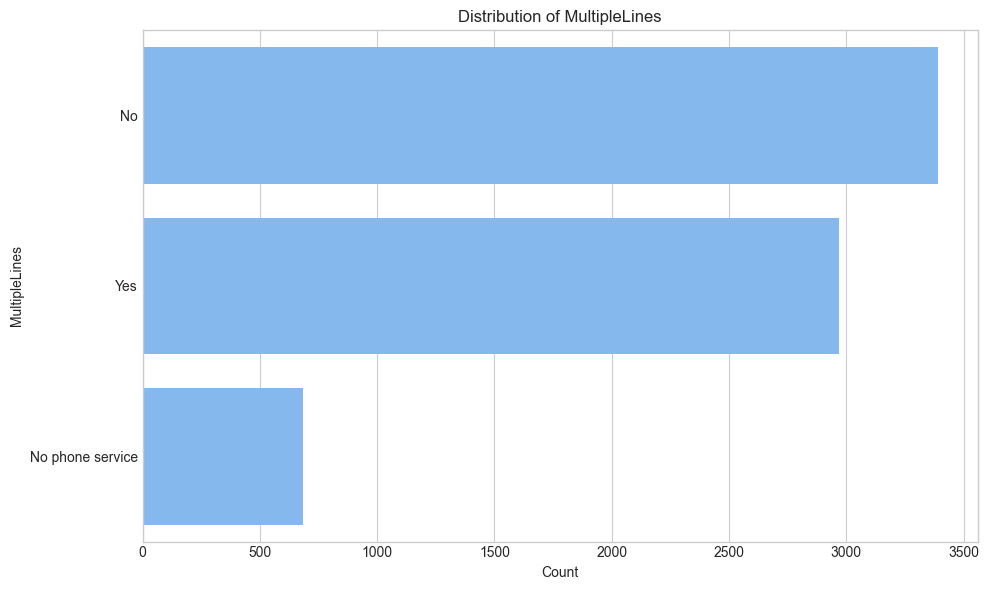

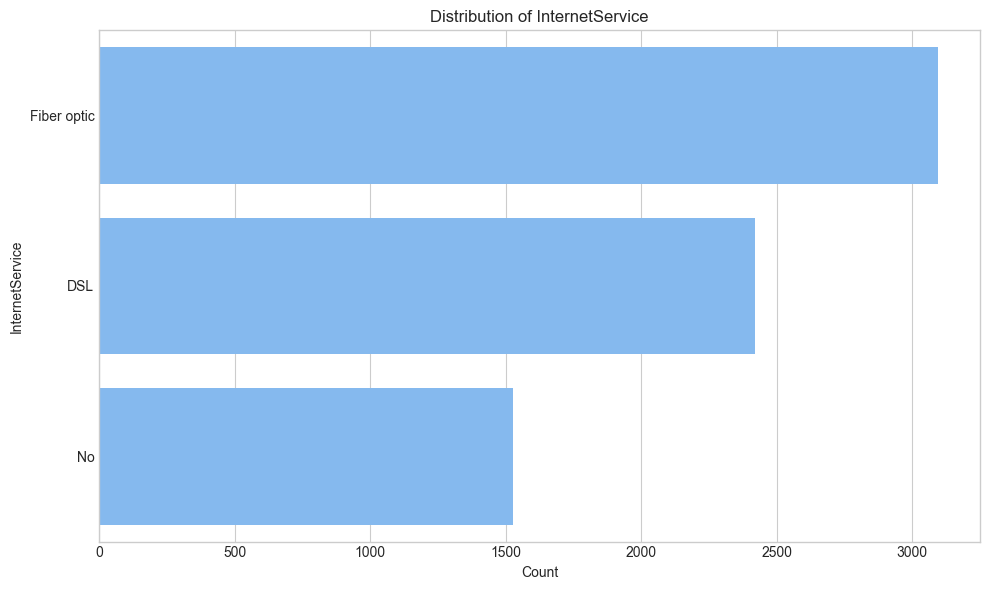

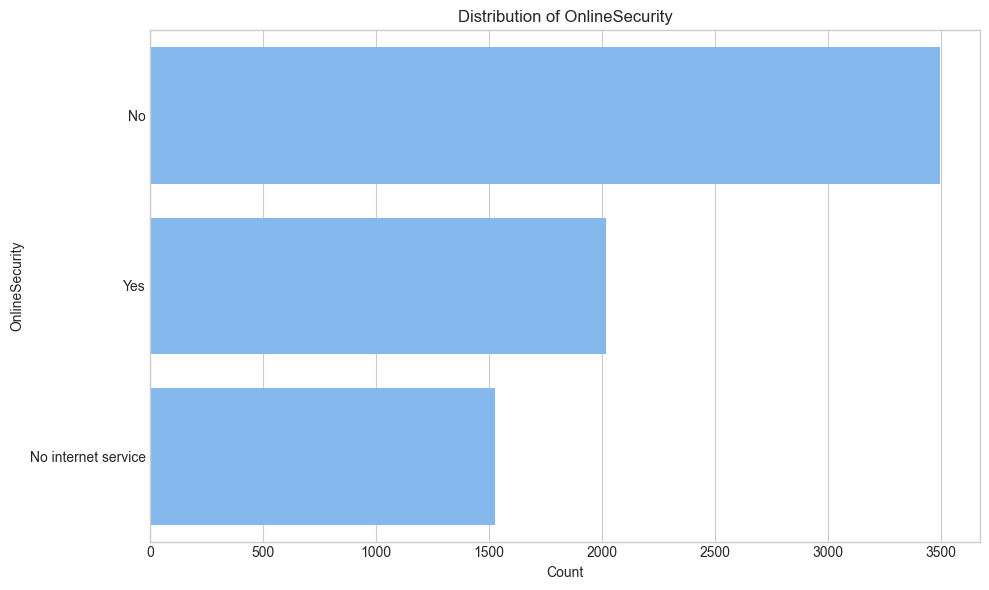

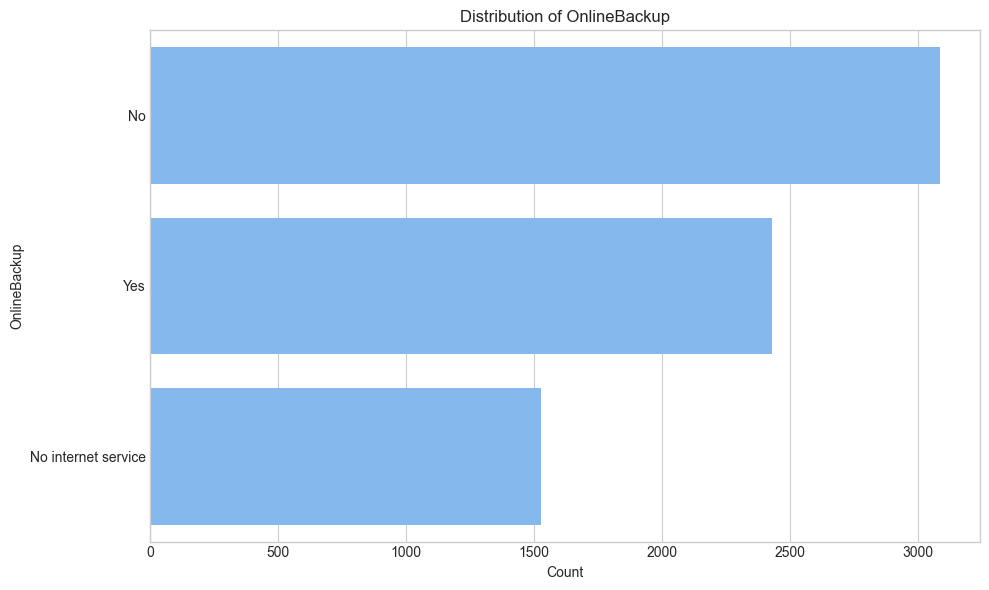

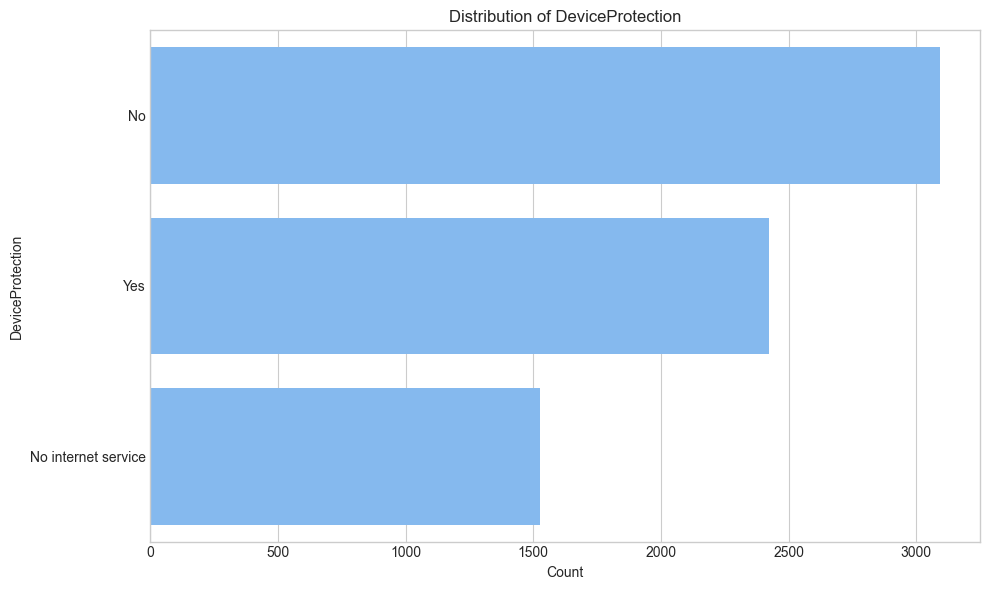

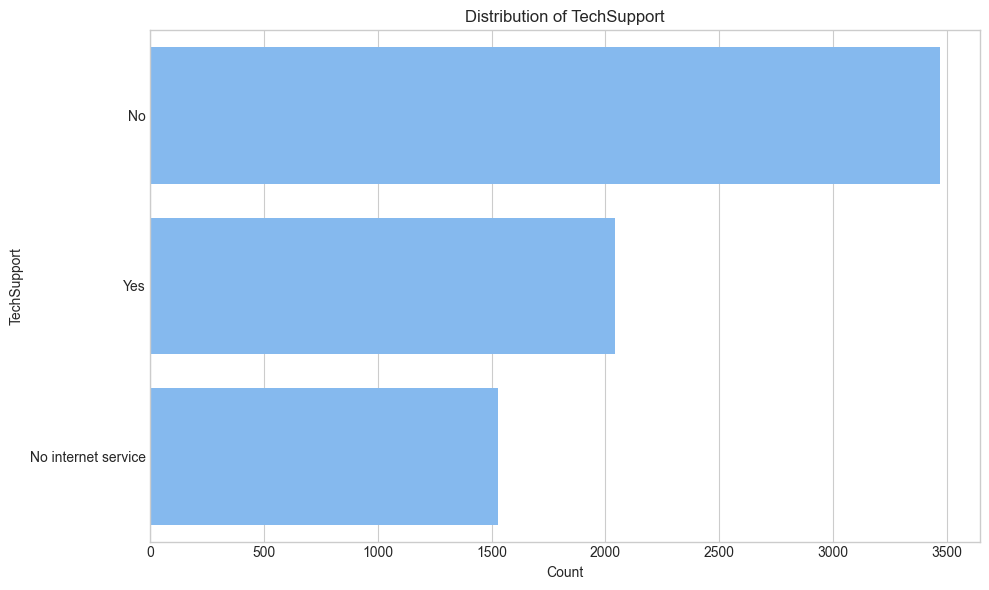

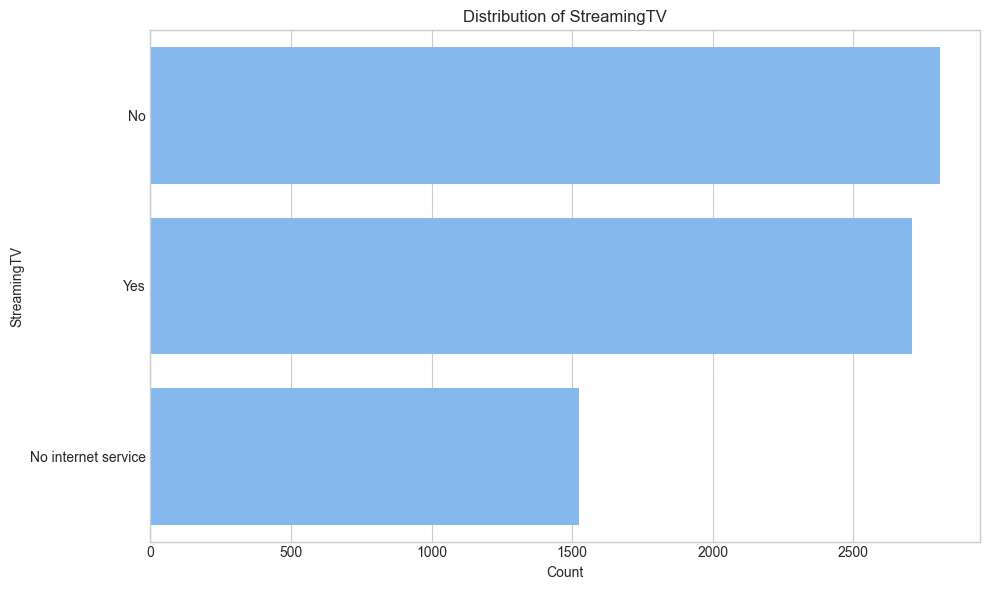

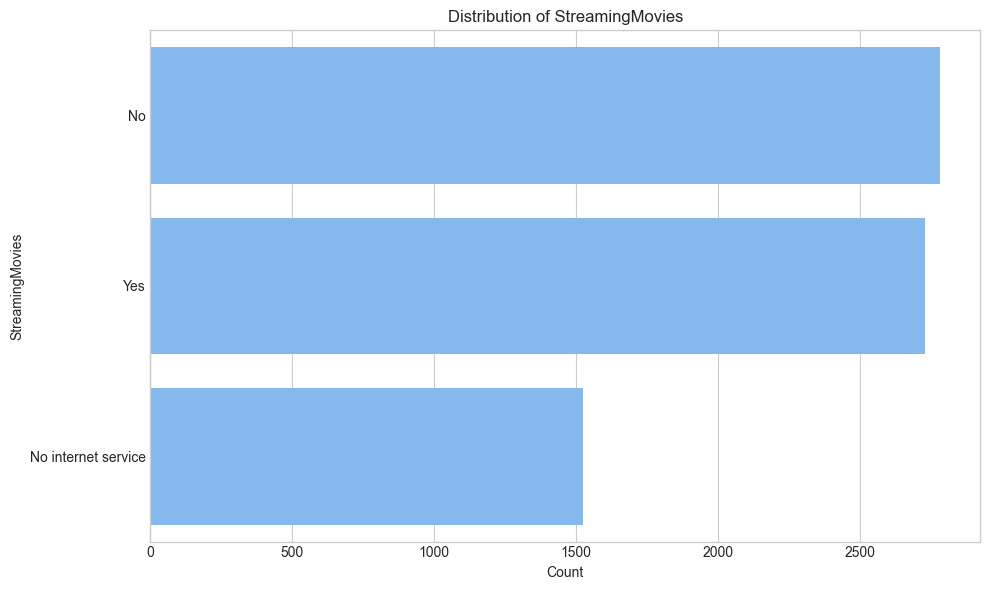

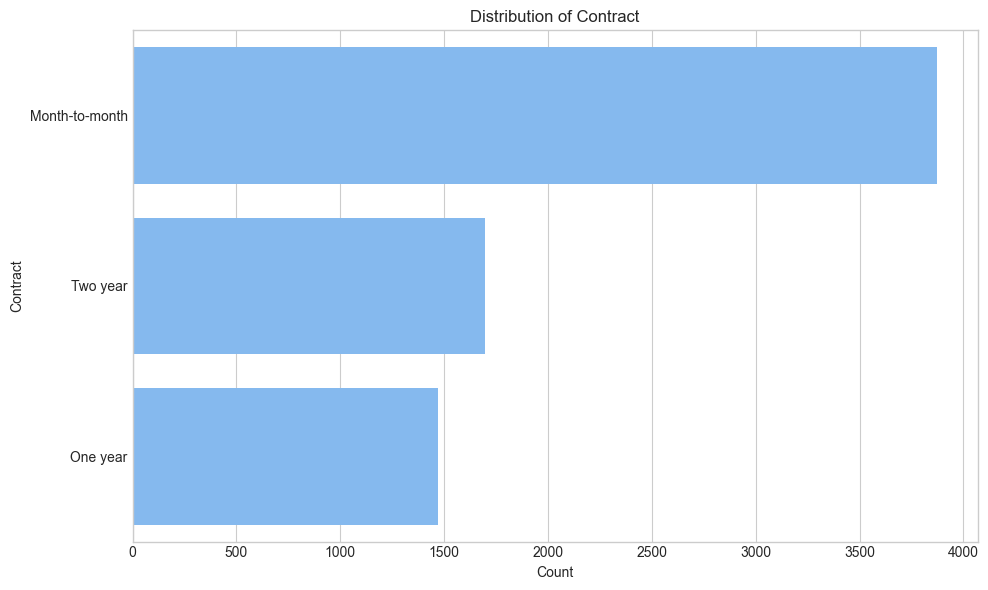

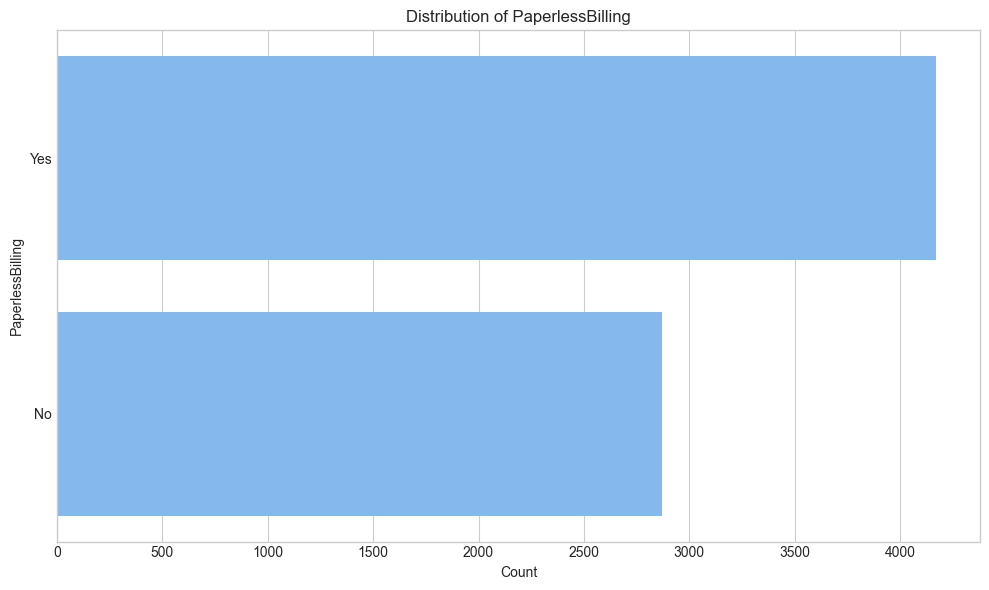

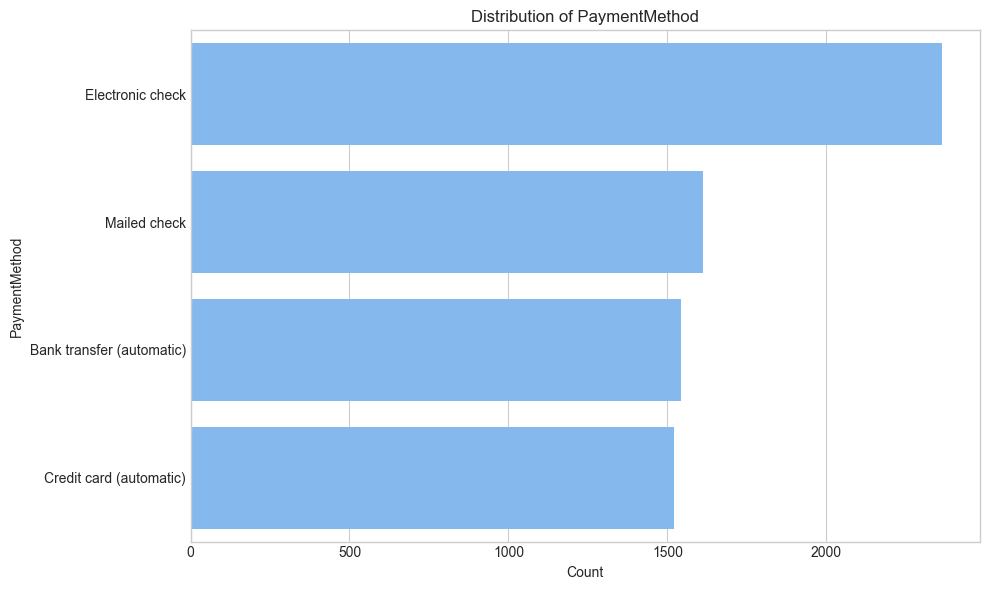

In [5]:
categorical_plot_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

for col in categorical_plot_cols:
    plt.figure(figsize=(10, 6))
    order = df[col].value_counts().index
    ax = sns.countplot(data=df, y=col, order=order, color="#74b9ff")
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    top_ratio = df[col].value_counts(normalize=True).iloc[0]
    if top_ratio >= 0.95:
        print(f"Near-zero-variance warning for {col}: top category ratio = {top_ratio:.2%}")

## Section 5: Bivariate Analysis - Features vs Churn

### Numeric vs Churn

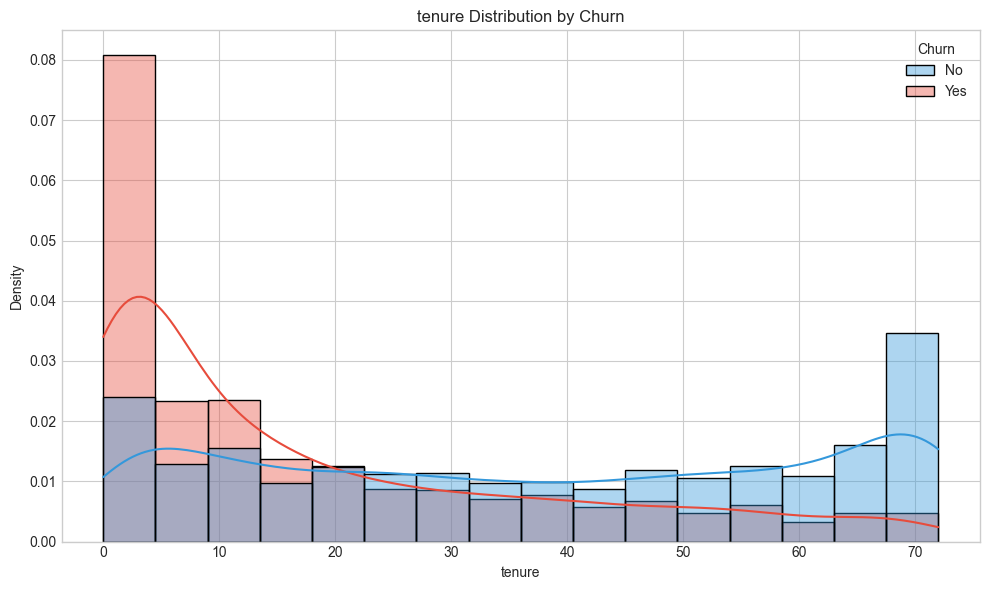

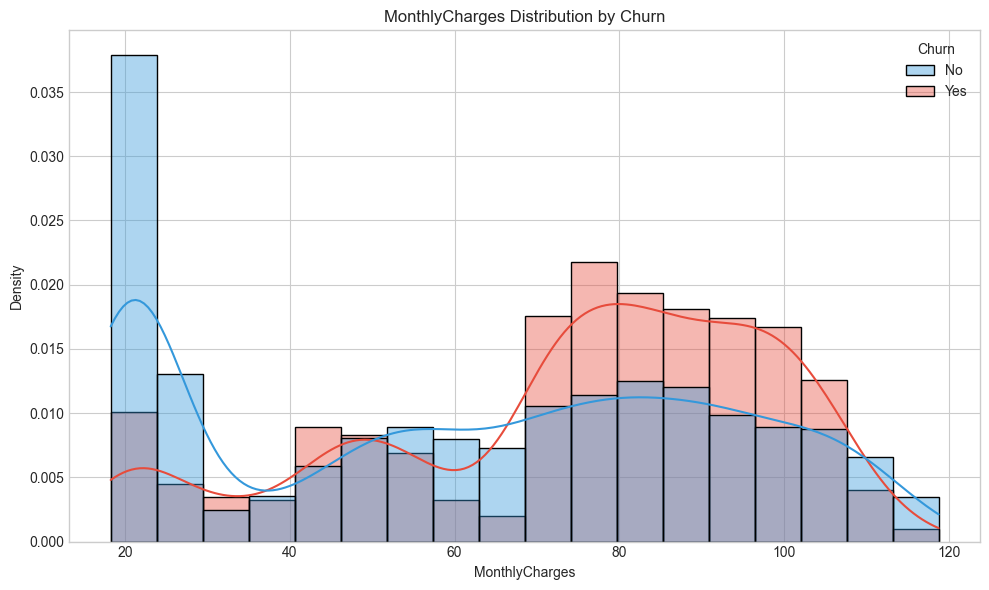

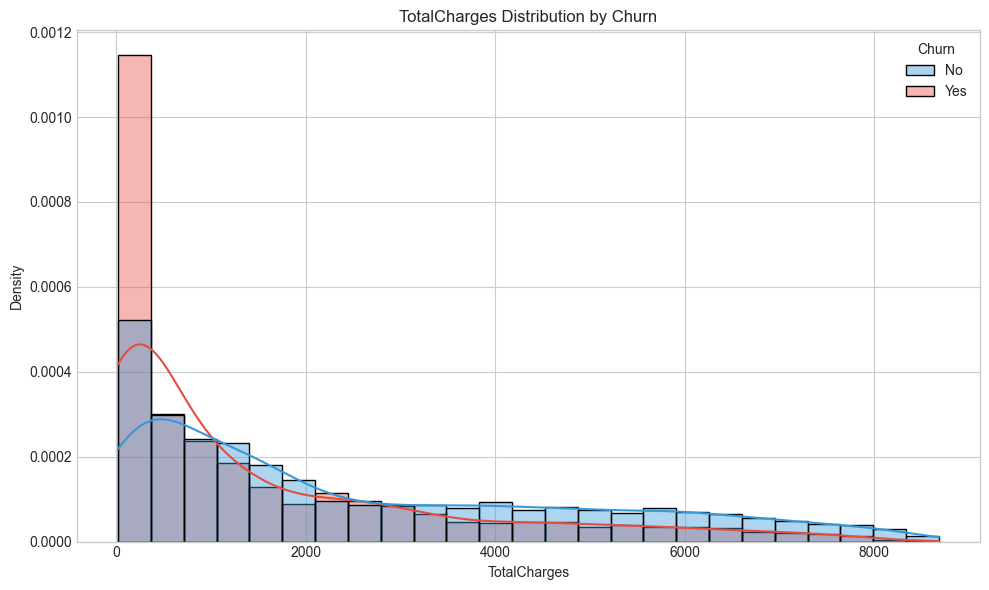

/var/folders/gt/lkmltst9197c2n38b3msfx1w0000gp/T/ipykernel_48158/2423242256.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_numeric, x="Churn", y=col, ax=axes[i], palette=churn_palette)
/var/folders/gt/lkmltst9197c2n38b3msfx1w0000gp/T/ipykernel_48158/2423242256.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_numeric, x="Churn", y=col, ax=axes[i], palette=churn_palette)


/var/folders/gt/lkmltst9197c2n38b3msfx1w0000gp/T/ipykernel_48158/2423242256.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_numeric, x="Churn", y=col, ax=axes[i], palette=churn_palette)


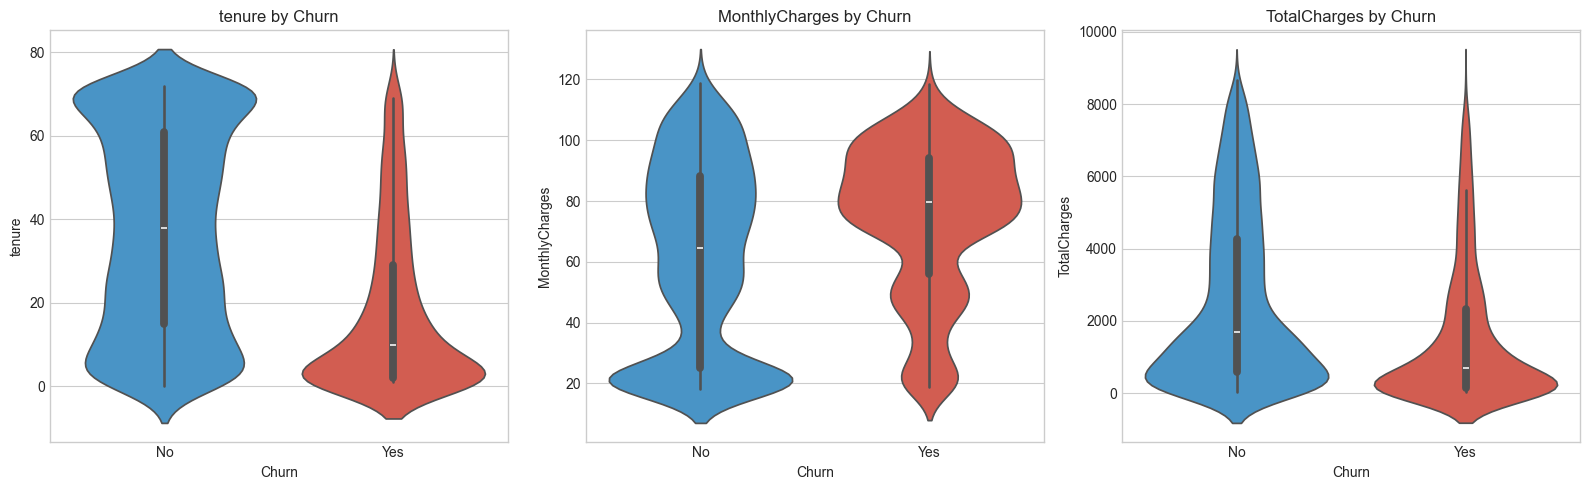

In [6]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_numeric,
        x=col,
        hue="Churn",
        kde=True,
        stat="density",
        common_norm=False,
        palette=churn_palette,
        alpha=0.4,
    )
    plt.title(f"{col} Distribution by Churn")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.violinplot(data=df_numeric, x="Churn", y=col, ax=axes[i], palette=churn_palette)
    axes[i].set_title(f"{col} by Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Categorical vs Churn

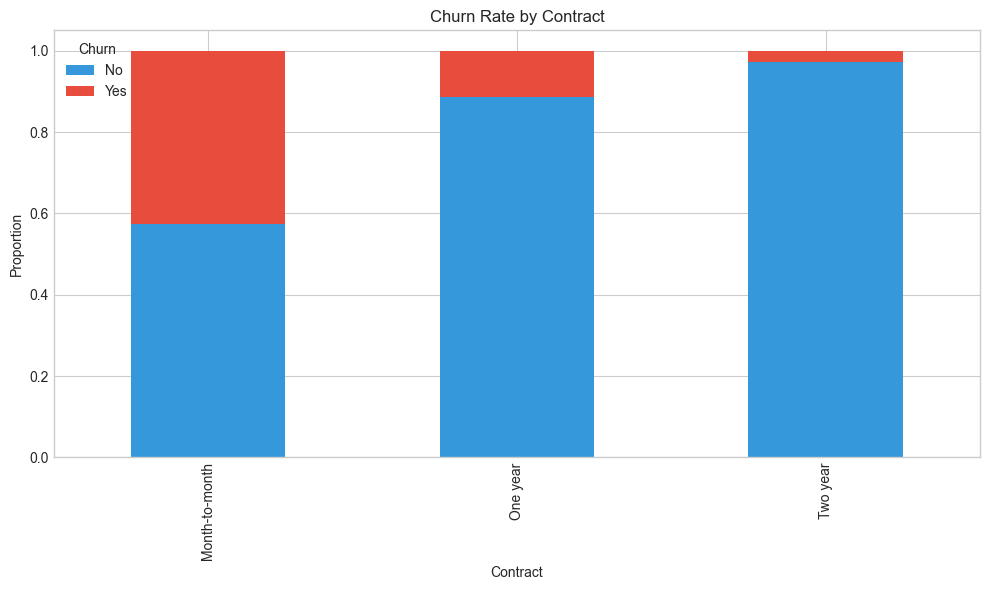


Top churn rates for Contract:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Yes, dtype: float64


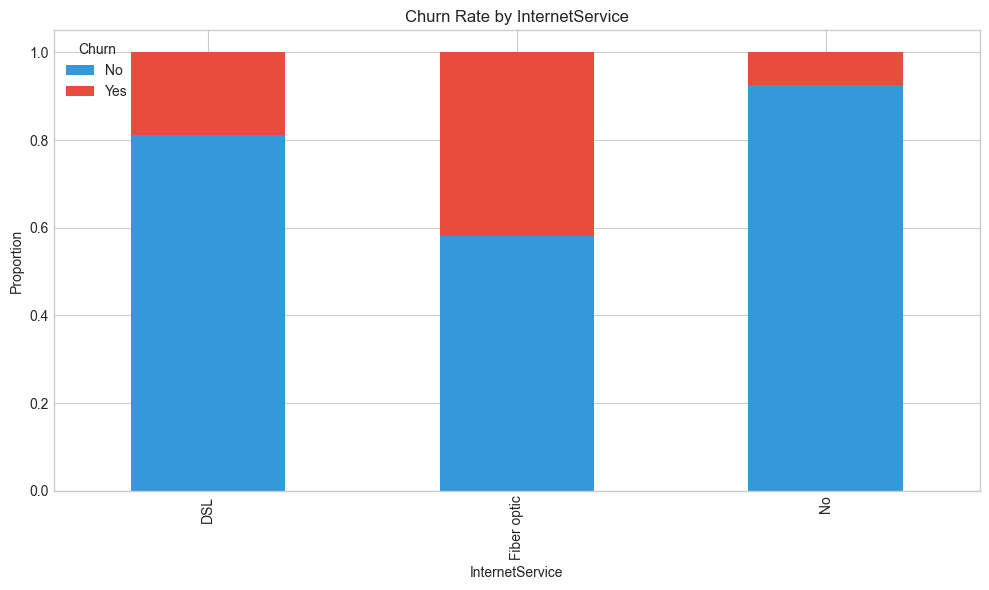


Top churn rates for InternetService:
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Yes, dtype: float64


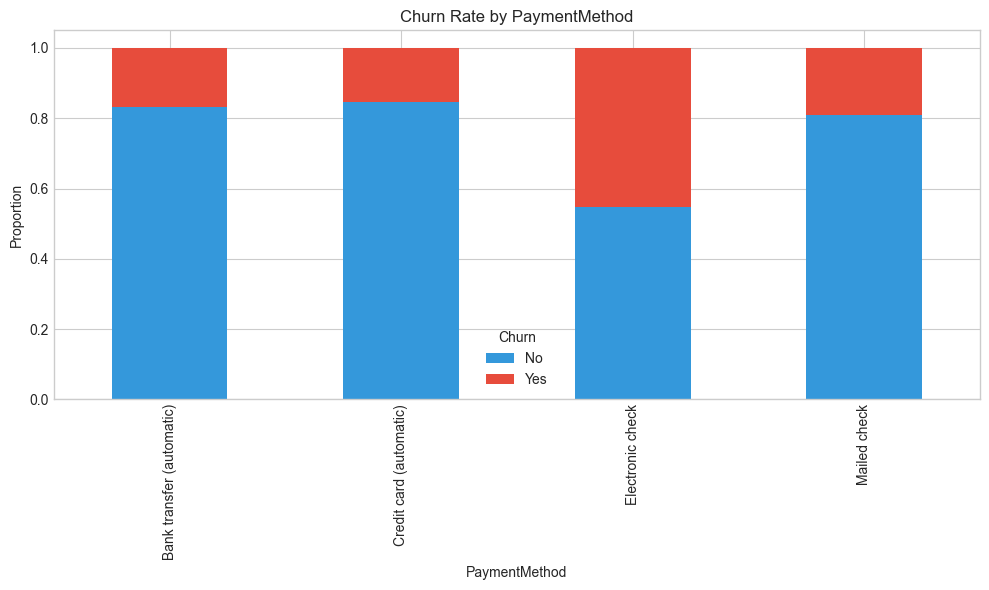


Top churn rates for PaymentMethod:
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Yes, dtype: float64


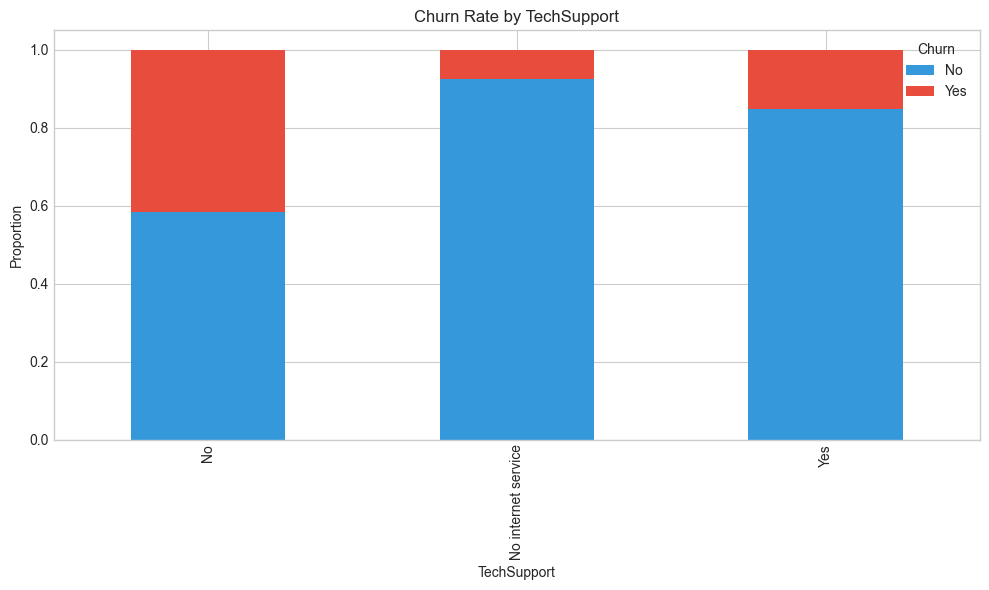


Top churn rates for TechSupport:
TechSupport
No                     0.416355
Yes                    0.151663
No internet service    0.074050
Name: Yes, dtype: float64


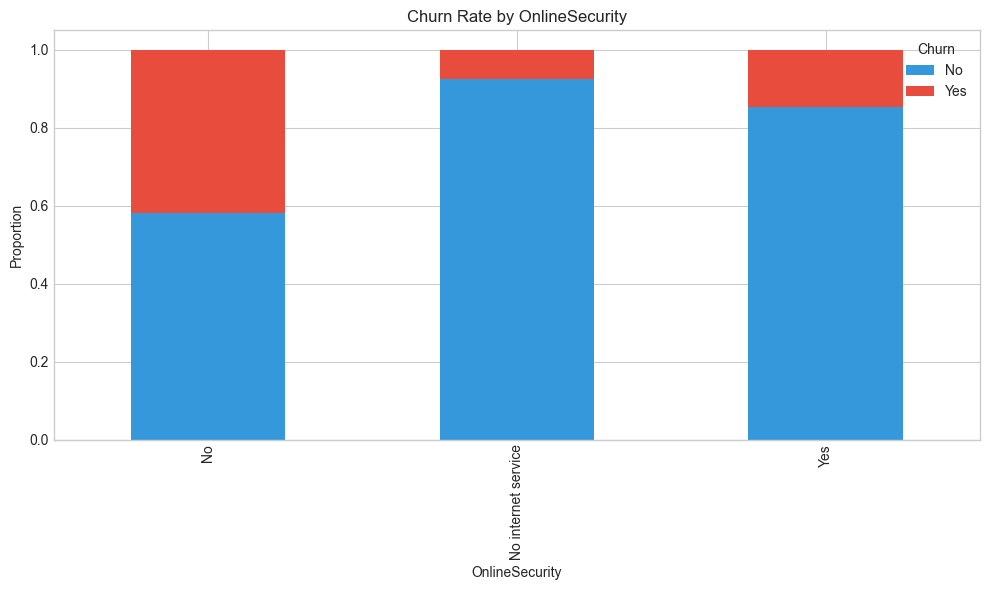


Top churn rates for OnlineSecurity:
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Yes, dtype: float64


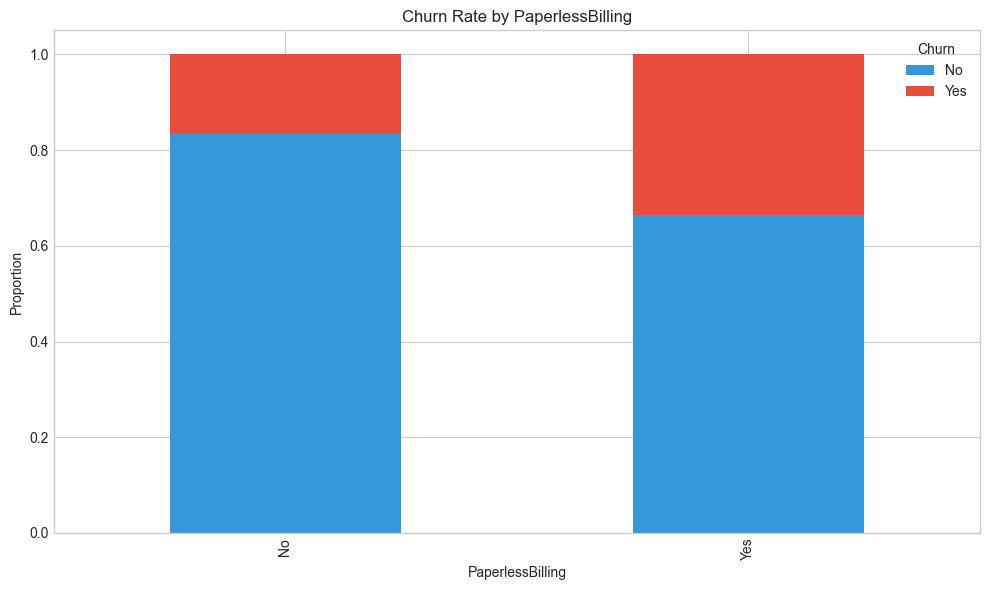


Top churn rates for PaperlessBilling:
PaperlessBilling
Yes    0.335651
No     0.163301
Name: Yes, dtype: float64


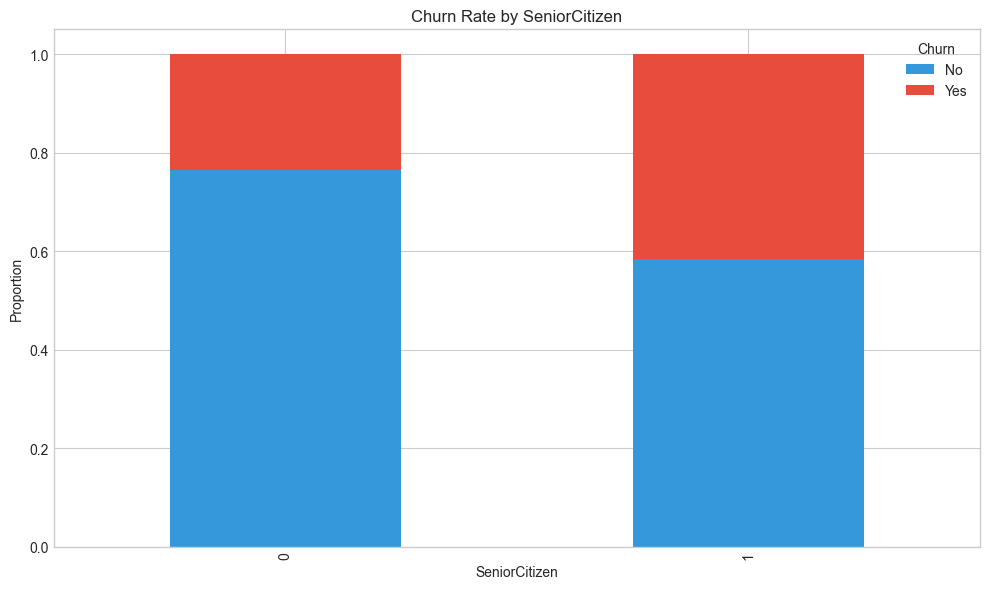


Top churn rates for SeniorCitizen:
SeniorCitizen
1    0.416813
0    0.236062
Name: Yes, dtype: float64


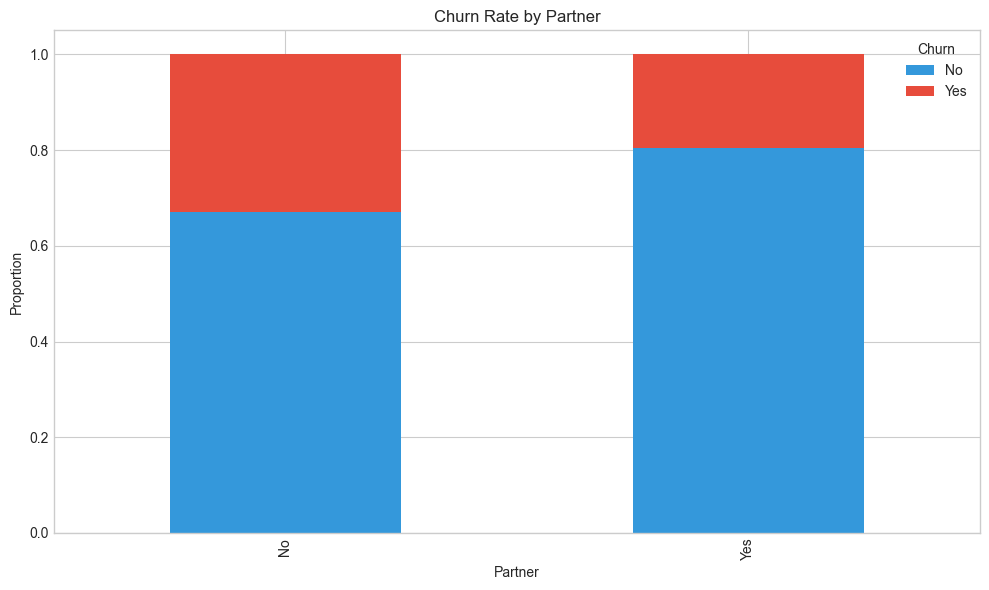


Top churn rates for Partner:
Partner
No     0.329580
Yes    0.196649
Name: Yes, dtype: float64


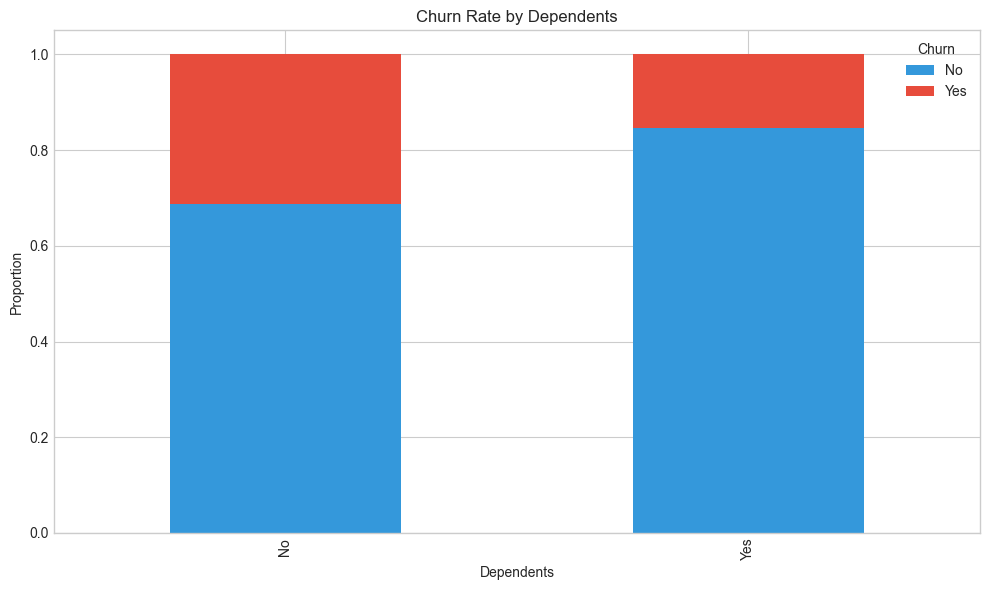


Top churn rates for Dependents:
Dependents
No     0.312791
Yes    0.154502
Name: Yes, dtype: float64


In [7]:
churn_rate_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling",
    "SeniorCitizen",
    "Partner",
    "Dependents",
]

for col in churn_rate_cols:
    churn_rate = pd.crosstab(df[col], df["Churn"], normalize="index")
    churn_rate = churn_rate[["No", "Yes"]] if {"No", "Yes"}.issubset(churn_rate.columns) else churn_rate

    ax = churn_rate.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        color=churn_palette,
    )
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

    print(f"\nTop churn rates for {col}:")
    if "Yes" in churn_rate.columns:
        print(churn_rate["Yes"].sort_values(ascending=False).head())

## Section 6: Correlation Analysis

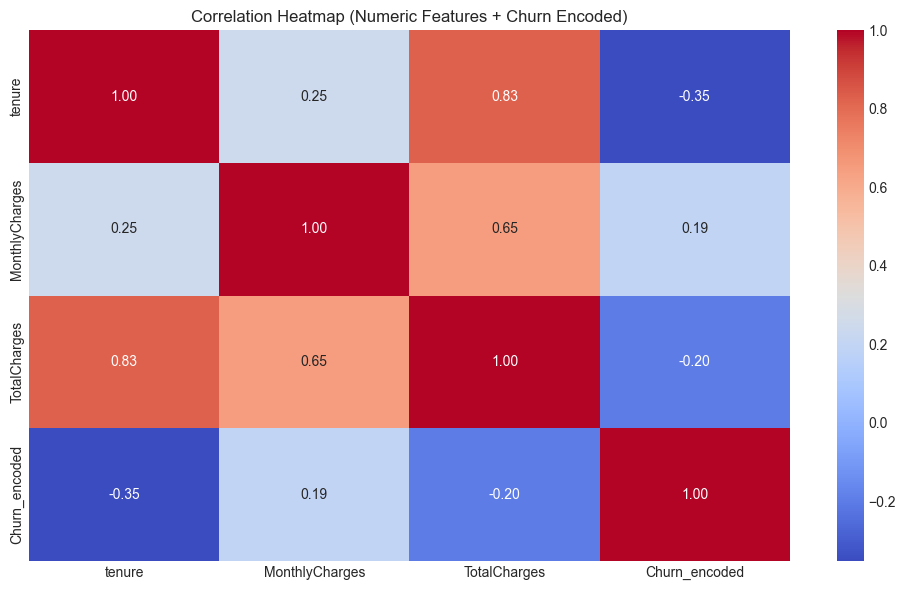

Expected relationships to verify:
- tenure and TotalCharges: strong positive
- MonthlyCharges and TotalCharges: moderate positive
- tenure and Churn_encoded: negative


In [8]:
corr_df = df_numeric[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["Churn_encoded"] = df["Churn"].map({"No": 0, "Yes": 1})

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features + Churn Encoded)")
plt.tight_layout()
plt.show()

print("Expected relationships to verify:")
print("- tenure and TotalCharges: strong positive")
print("- MonthlyCharges and TotalCharges: moderate positive")
print("- tenure and Churn_encoded: negative")

## Section 7: Summary of Findings

### Top features associated with churn (visual evidence)

- `Contract`: Month-to-month customers show much higher churn than one/two-year contracts.
- `tenure`: Short-tenure customers are overrepresented in churn.
- `MonthlyCharges`: Higher monthly charges are associated with higher churn risk.
- `InternetService`: Fiber optic users tend to churn more than DSL users.
- `PaymentMethod`: Electronic check has a higher churn proportion.
- `TechSupport` and `OnlineSecurity`: Lack of support/security is linked with higher churn.
- `SeniorCitizen`: Churn tends to be higher within senior-citizen customers.

### Data quality findings

- `TotalCharges` includes whitespace strings and should be converted using `pd.to_numeric(..., errors="coerce")` in preprocessing.
- No true null values were found in the raw dataframe.
- No duplicate `customerID` rows were identified.

### Class imbalance

- Target distribution is approximately 73% `No` and 27% `Yes`.
- This is moderate imbalance and warrants class-weighted models and/or resampling in Phase 3.

### Hypotheses to validate during modeling

- Contract type is likely one of the strongest churn drivers.
- Tenure and monthly charges likely provide strong predictive signal.
- Service/support availability features may provide additive predictive value.

### Phase 2 feature-engineering recommendations

- Bucket `tenure` into business-friendly groups.
- Create `avg_monthly_charge = TotalCharges / tenure` (handle zero-tenure safely).
- Create `service_count` by counting subscribed add-on services.
- Create `has_premium_support` from `TechSupport` + `OnlineSecurity`.